In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline
route_imp = 'best_model_gpa_imp.keras'

I0000 00:00:1780505298.839516    5850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780505298.911911    5850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780505300.201620    5850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,0.039790,0.635270,0.389414,1.029957,0.987837,0.010287,-0.158692,0.487645,0.161424,1,0,0,2.02
1,-1.448469,-1.144237,0.037988,-1.008673,0.635270,1.244780,-0.158692,1.186360,-0.547807,1,1,0,3.34
2,1.031963,-1.399657,-0.714776,1.194396,-0.295415,1.244780,-0.849597,1.186360,0.516039,1,0,1,3.57


In [3]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,-0.456296,0.012660,0.282216,-0.229884,0.987837,0.010287,-0.504145,0.487645,1.579885,1,0,0,3.16
1,0.535877,-1.639976,0.229884,0.714776,1.690622,0.010287,-0.504145,1.535718,0.870654,0,1,0,3.06
2,0.535877,-1.144237,-1.168949,-0.037988,-5.199338,0.010287,1.223118,-0.560428,-1.257037,1,0,0,2.65


In [4]:
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test = df_test.copy()
y_test.head()

0    2.02
1    3.34
2    3.57
3    2.15
4    3.47
Name: target_academic_performance, dtype: float64

In [5]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,0.039790,0.635270,0.389414,1.029957,0.987837,0.010287,-0.158692,0.487645,0.161424,1,0,0
1,-1.448469,-1.144237,0.037988,-1.008673,0.635270,1.244780,-0.158692,1.186360,-0.547807,1,1,0
2,1.031963,-1.399657,-0.714776,1.194396,-0.295415,1.244780,-0.849597,1.186360,0.516039,1,0,1
3,-0.456296,0.362241,-1.690622,0.050661,-1.051717,0.010287,-1.540502,1.535718,-0.193191,1,0,1
4,-0.952383,1.704781,-0.178175,-1.168949,0.635270,0.010287,1.223118,1.535718,1.225270,0,1,0


In [6]:
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train = df_train.copy()
y_train.head()

0    3.16
1    3.06
2    2.65
3    2.92
4    3.82
Name: target_academic_performance, dtype: float64

In [7]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,-0.456296,0.012660,0.282216,-0.229884,0.987837,0.010287,-0.504145,0.487645,1.579885,1,0,0
1,0.535877,-1.639976,0.229884,0.714776,1.690622,0.010287,-0.504145,1.535718,0.870654,0,1,0
2,0.535877,-1.144237,-1.168949,-0.037988,-5.199338,0.010287,1.223118,-0.560428,-1.257037,1,0,0
3,-0.456296,-2.049594,0.515705,1.194396,0.486994,-1.224205,-0.849597,0.487645,-0.547807,1,0,0
4,-1.448469,0.255962,0.088734,0.870846,-0.178175,0.010287,0.877665,0.837002,0.161424,1,0,1


In [8]:
BATCH_SIZE = 16

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train.values, test_size=0.15
)

train_pipeline = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_pipeline = train_pipeline.shuffle(buffer_size=len(X_train_final)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy())).batch(BATCH_SIZE)

E0000 00:00:1780505302.336171    5850 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
input_shape_dim = X_train_final.shape[1]
model_imp = tf.keras.Sequential([
   tf.keras.layers.Input(shape=(input_shape_dim,)),
    
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='swish'),    
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1)
])

In [10]:
checkpoint_callback_imp = ModelCheckpoint(
    filepath=route_imp,       
    monitor='val_mae',         
    save_best_only=True,        
    mode='min',                 
    verbose=1                   
)
early_stop = EarlyStopping(
    monitor='val_mae', 
    patience=16, 
    restore_best_weights=True
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_mae', 
    factor=0.2,  
    patience=5,      
    min_lr=1e-5,     
    verbose=1
)

In [11]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

model_imp.compile(
    optimizer=optimizer,             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [12]:
history_imp = model_imp.fit(
    train_pipeline,
    epochs=100, 
    validation_data=val_dataset,
    callbacks=[checkpoint_callback_imp, lr_reducer, early_stop],
    verbose=1)

Epoch 1/100
41/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.5308 - mae: 2.8378 - rmse: 2.9187   
Epoch 1: val_mae improved from None to 1.89766, saving model to best_model_gpa_imp.keras

Epoch 1: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9999 - mae: 2.5307 - rmse: 2.6457 - val_loss: 4.1464 - val_mae: 1.8977 - val_rmse: 2.0363 - learning_rate: 0.0010
Epoch 2/100
33/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7551 - mae: 1.7359 - rmse: 1.9313
Epoch 2: val_mae improved from 1.89766 to 0.84791, saving model to best_model_gpa_imp.keras

Epoch 2: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5044 - mae: 1.3434 - rmse: 1.5825 - val_loss: 1.1668 - val_mae: 0.8479 - val_rmse: 1.0802 - learning_rate: 0.0010
Epoch 3/100
34/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4697 - mae: 1.0059 - rmse: 1.2118
Epoch 3: val_mae improved from 0.84791 to 0.71925, saving model to best_model_gpa_imp

In [13]:
test_loss, test_mae, test_rmse = model_imp.evaluate(test_dataset, verbose=1)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3580 - mae: 0.5090 - rmse: 0.5983

Test MSE (Loss): 0.3580
Test MAE: 0.5090
Test RMSE: 0.5983


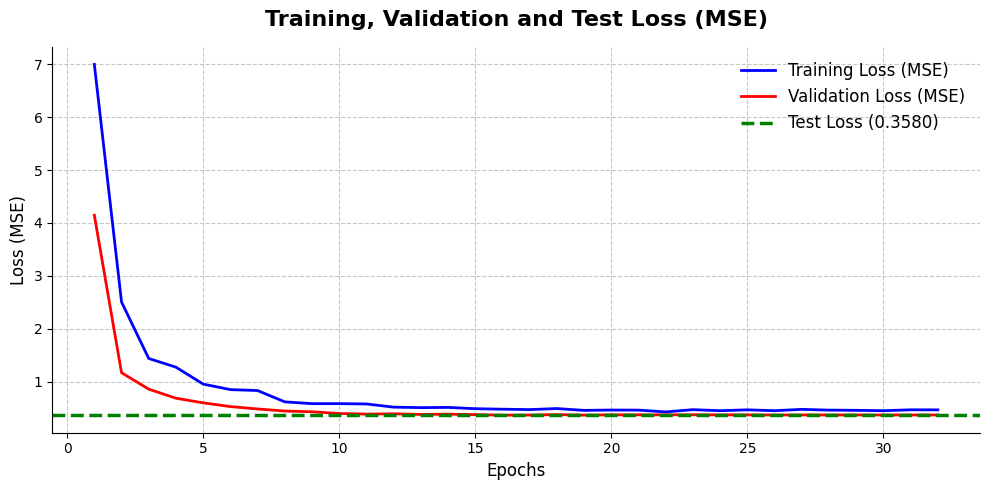

In [14]:
epochs = range(1, len(history_imp.history['loss']) + 1)
train_loss = history_imp.history['loss']
val_loss = history_imp.history['val_loss']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss ({test_loss:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test Loss (MSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

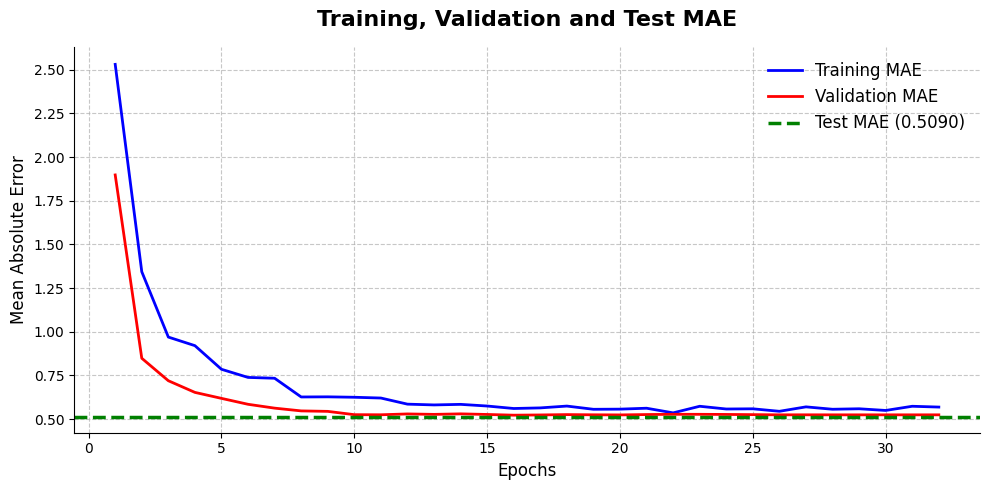

In [15]:
epochs = range(1, len(history_imp.history['mae']) + 1)
train_mae = history_imp.history['mae']
val_mae = history_imp.history['val_mae']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_mae, 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE', linewidth=2)
plt.axhline(y=test_mae, color='g', linestyle='--', label=f'Test MAE ({test_mae:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test MAE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

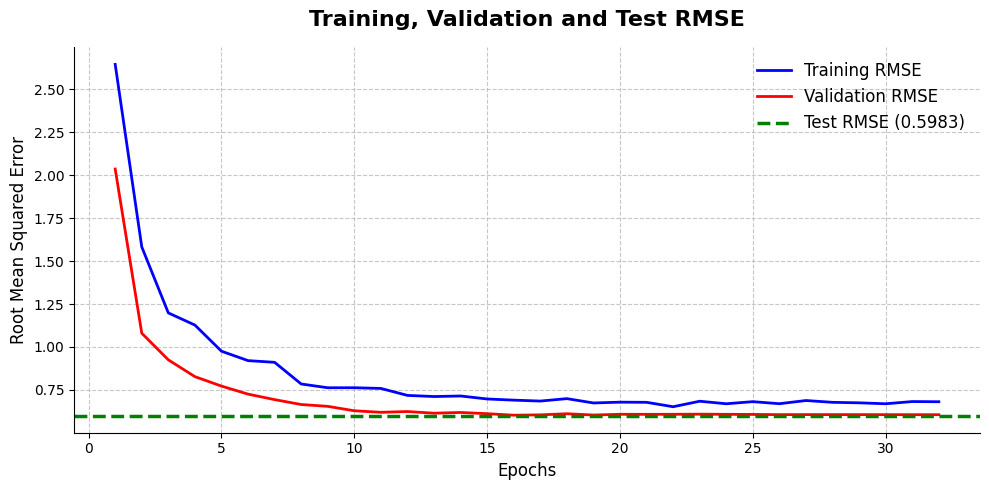

In [16]:
epochs = range(1, len(history_imp.history['rmse']) + 1)
train_rmse = history_imp.history['rmse']
val_rmse = history_imp.history['val_rmse']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_rmse, 'b-', label='Training RMSE', linewidth=2)
plt.plot(epochs, val_rmse, 'r-', label='Validation RMSE', linewidth=2)

plt.axhline(y=test_rmse, color='g', linestyle='--', label=f'Test RMSE ({test_rmse:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test RMSE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
final_train_loss = history_imp.history['loss'][-1]
final_val_loss = history_imp.history['val_loss'][-1]

final_train_mae = history_imp.history['mae'][-1]
final_val_mae = history_imp.history['val_mae'][-1]

final_train_rmse = history_imp.history['rmse'][-1]
final_val_rmse = history_imp.history['val_rmse'][-1]

data = {
    'Métrica': ['MSE (Loss)', 'MAE', 'RMSE'],
    'Train': [final_train_loss, final_train_mae, final_train_rmse],
    'Validation': [final_val_loss, final_val_mae, final_val_rmse],
    'Test': [test_loss, test_mae, test_rmse]
}

df_metrics = pd.DataFrame(data).round(4)
df_metrics

,Métrica,Train,Validation,Test
0,MSE (Loss),0.4640,0.3669,0.3580
1,MAE,0.5684,0.5240,0.5090
2,RMSE,0.6811,0.6057,0.5983
